In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import bacco

In [4]:
base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/LH_0/hydro_output/"

sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

snap = 237

zoom_new = bacco.Simulation(
            basedir=base,
            halo_file="groups_{0:03d}/fof_subhalo_tab_{0:03d}".format(snap),
            sim_format='TNG500', fixedPk=True, use_orphans=False,
            tau=tau,
            ns=ns,
            sigma8=sigma8,
            use_ids=False,
            tree_file="groups_{0:03d}/subhalo_prog_{0:03d}".format(snap),
            dm_file="snapdir_{0:03d}/snapshot_{0:03d}".format(snap),
            numpart=4320,
        )

2026-05-25 16:31:27,118 bacco.sims : Initialising simulation Default
2026-05-25 16:31:27,119 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_0/hydro_output/snapdir_237/snapshot_237
2026-05-25 16:31:27,143 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_0/hydro_output/snapdir_237/snapshot_237


2026-05-25 16:31:27,158 bacco.sims : ...done in 0.0399 s


In [5]:
base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/old_LH0/hydro_output/"

zoom_old = bacco.Simulation(
            basedir=base,
            halo_file="groups_{0:03d}/fof_subhalo_tab_{0:03d}".format(snap),
            sim_format='TNG500', fixedPk=True, use_orphans=False,
            tau=tau,
            ns=ns,
            sigma8=sigma8,
            use_ids=False,
            tree_file="groups_{0:03d}/subhalo_prog_{0:03d}".format(snap),
            dm_file="snapdir_{0:03d}/snapshot_{0:03d}".format(snap),
            numpart=4320,
        )

2026-05-25 16:31:37,039 bacco.sims : Initialising simulation Default
2026-05-25 16:31:37,041 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/old_LH0/hydro_output/snapdir_237/snapshot_237
2026-05-25 16:31:37,085 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/old_LH0/hydro_output/snapdir_237/snapshot_237
2026-05-25 16:31:37,103 bacco.sims : ...done in 0.0635 s


In [67]:
base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/"

zoom_other = bacco.Simulation(
            basedir=base,
            halo_file="groups_{0:03d}/fof_subhalo_tab_{0:03d}".format(snap),
            sim_format='TNG500', fixedPk=True, use_orphans=False,
            tau=tau,
            ns=ns,
            sigma8=sigma8,
            use_ids=False,
            tree_file="groups_{0:03d}/subhalo_prog_{0:03d}".format(snap),
            dm_file="snapdir_{0:03d}/snapshot_{0:03d}".format(snap),
            numpart=4320,
        )

2026-05-25 17:35:20,361 bacco.sims : Initialising simulation Default
2026-05-25 17:35:20,363 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/snapdir_237/snapshot_237
2026-05-25 17:35:20,407 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/snapdir_237/snapshot_237
2026-05-25 17:35:20,426 bacco.sims : ...done in 0.0653 s


2026-05-25 17:35:20,769 bacco.sims : Reading 81919 items for SubhaloMassType


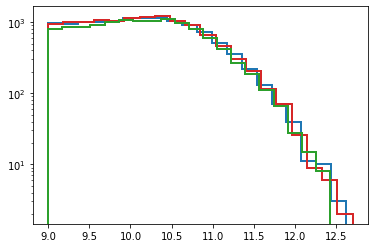

In [68]:
mask = zoom_new.sub['MassType'][:,4] > 0.1 
hist = plt.hist(np.log10(1e10*zoom_new.sub['MassType'][mask,4]), log=True, histtype='step', lw=2, bins=20)

mask = zoom_old.sub['MassType'][:,4] > 0.1 
hist = plt.hist(np.log10(1e10*zoom_old.sub['MassType'][mask,4]), log=True, histtype='step', lw=2, color="C3", bins=20)

mask = zoom_other.sub['MassType'][:,4] > 0.1 
hist = plt.hist(np.log10(1e10*zoom_other.sub['MassType'][mask,4]), log=True, histtype='step', lw=2, color="C2", bins=20)

In [19]:
print(zoom_new.fof['halo_pos'][0,:])
print(zoom_old.fof['halo_pos'][0,:])

[ 88.11126 319.76578 372.80573]
[ 88.119835 319.7485   372.80826 ]


### Compare a number of their properties

In [25]:
keys = ['halo_m200c', 'halo_m500c', 'halo_nsubs']

for key in keys:
    print(key, zoom_new.fof[key][0] / zoom_old.fof[key][0])

halo_m200c 1.0169644
halo_m500c 1.0156654
halo_nsubs 1.0124925639500297


In [51]:
print(zoom_new.sub['pos'][0,:])
print(zoom_old.sub['pos'][0,:])

[ 87.11742 317.60107 373.99503]
[ 87.12455 317.59567 373.994  ]


In [32]:
zoom_new.sub.keys()

dict_keys(['nsubs_in_file', 'pos', 'vel', 'mostboundID', 'len', 'subnr', 'fof_index', 'central', 'vmax', 'rmax', 'vpeak', 'peak_time', 'mpeak', 'vel_core', 'id', 'id_offsets', 'star_id_offsets', 'mdot_at_mpeak', 'mdot', 'orphan_snap', 'infall_snap', 'subhalo_moment_of_inertia', 'subhalo_stellar_MOI', 'subhalo_red_moi', 'star_red_moi', 'subhalo_core_moi', 'star_core_moi', 'subhalo_bound_moi', 'star_bound_moi', 'subhalo_bound_moi_25', 'star_bound_moi_25', 'subhalo_bound_moi_75', 'star_bound_moi_75', 'subhalo_bound_moi_95', 'star_bound_moi_95', 'subhalo_bound_moi_90', 'star_bound_moi_90', 'subhalo_bound_moi_85', 'star_bound_moi_85', 'subhalo_bound_moi_80', 'star_bound_moi_80', 'bias', 'BHMdot', 'StarMetalFractions', 'WindMass', 'GasMetallicityMaxRad', 'VelDisp', 'SFR', 'StarMetallicityMaxRad', 'SFRinHalfRad', 'StarMetalFractionsHalfRad', 'GasMetalFractionsMaxRad', 'GasMetallicity', 'BHMass', 'IDMostbound', 'HalfmassRad', 'Parent', 'Spin', 'GasMetalFractions', 'StarMetallicityHalfRad', 'Le

In [54]:
keys = ['SubhaloKineticEnergyStars', 'SubhaloRotationalEnergyStars', 'StarMetallicity', 'SFR']

for key in keys:
    print(key, zoom_new.sub[key][0] / zoom_old.sub[key][0])

SubhaloKineticEnergyStars 0.9637354
SubhaloRotationalEnergyStars 1.0310448
StarMetallicity 1.039477
SFR 3.6720898


In [55]:
print(zoom_new.sub['MassType'][0,0] / zoom_old.sub['MassType'][0,0])
print(zoom_new.sub['MassType'][0,1] / zoom_old.sub['MassType'][0,1])
print(zoom_new.sub['MassType'][0,4] / zoom_old.sub['MassType'][0,4])
print(zoom_new.sub['MassType'][0,5] / zoom_old.sub['MassType'][0,5])

0.9866559
0.9975192
0.96372724
1.0690544
